<a href="https://colab.research.google.com/github/kwonsyno1/2024promotion/blob/main/2026_%EC%97%B0%EC%88%98%EC%9A%A9_%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. 데이터 분석

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from google.colab import files
import matplotlib.font_manager as fm

# 한글 폰트 깨짐 방지 (코랩용)
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf
# matplotlib의 폰트 캐시를 다시 빌드하여 새로 설치된 폰트를 인식시킵니다.
# fm._rebuild() # 이 줄을 제거하여 오류를 해결합니다.
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 기호 깨짐 방지

# 1. 파일 업로드
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 파일 확장자에 따라 적절한 함수 사용
if file_name.endswith('.xlsx') or file_name.endswith('.xls'):
    df = pd.read_excel(file_name)
else:
    # CSV 파일인 경우 한글 깨짐 방지를 위해 encoding 추가
    try:
        df = pd.read_csv(file_name, encoding='utf-8')
    except UnicodeDecodeError:
        df = pd.read_csv(file_name, encoding='cp949')

print("데이터 로드 완료!")
df.head() # 데이터 상단 5행 출력

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 2 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/n

Saving 고리 비행기 데이터(1학년).xlsx to 고리 비행기 데이터(1학년) (2).xlsx
데이터 로드 완료!


,앞쪽고리지름(cm),앞쪽고리두께(cm),뒤쪽고리지름(cm),뒤쪽고리두께(cm),전체 길이(cm),무게 중심 거리(cm),비행체 전체 질량(g),두 고리 간 지름 비율(자동),무게중심비율(자동),시간1(s),거리1(cm),시간2(s),거리2(cm),시간3(s),거리3(cm),비행성능1(자동),비행성능2(자동),비행성능3(자동),평균값(자동)
0,6.0,4.0,9.0,2.0,25.0,12.0,3.1,0.666667,0.48,2.0,370.0,2.0,170.0,1.7,100.0,740.0,340.0,170.0,416.666667
1,13.5,3.0,13.5,3.0,25.0,12.5,3.9,1.000000,0.50,1.5,10.0,1.4,10.0,1.5,-10.0,15.0,14.0,-15.0,4.666667
2,2.2,2.0,9.6,13.6,25.0,16.0,6.2,0.229167,0.64,1.2,120.0,1.4,150.0,1.1,14.0,144.0,210.0,15.4,123.133333
3,8.5,3.0,8.5,3.0,20.0,10.0,2.8,1.000000,0.50,1.8,200.0,2.3,260.0,2.5,270.0,360.0,598.0,675.0,544.333333
4,8.5,4.0,8.5,2.0,25.0,7.5,3.3,1.000000,0.30,1.5,35.0,2.0,400.0,2.5,410.0,52.5,800.0,1025.0,625.833333


2. 데이터 시각화 및 상관관계 분석

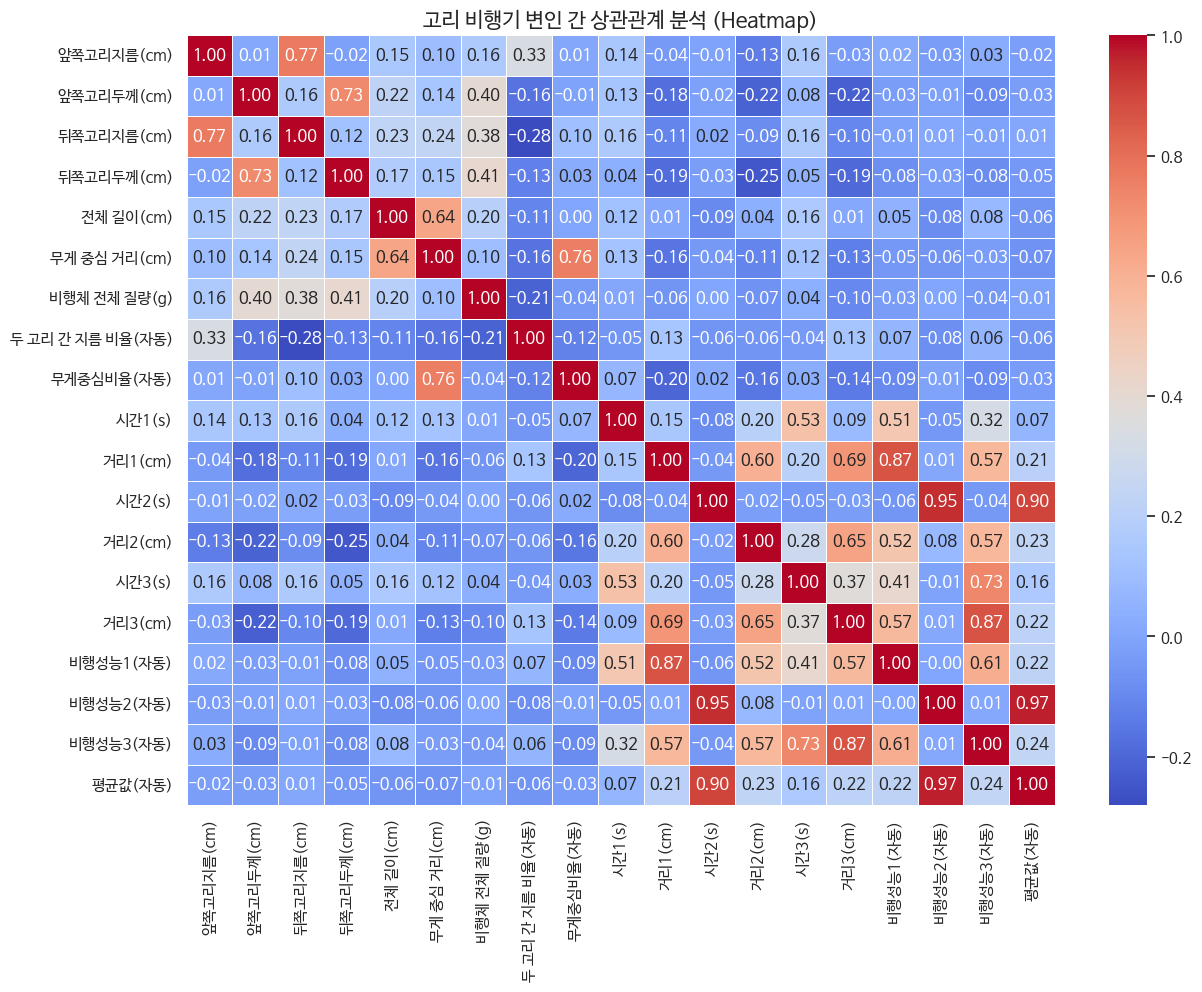

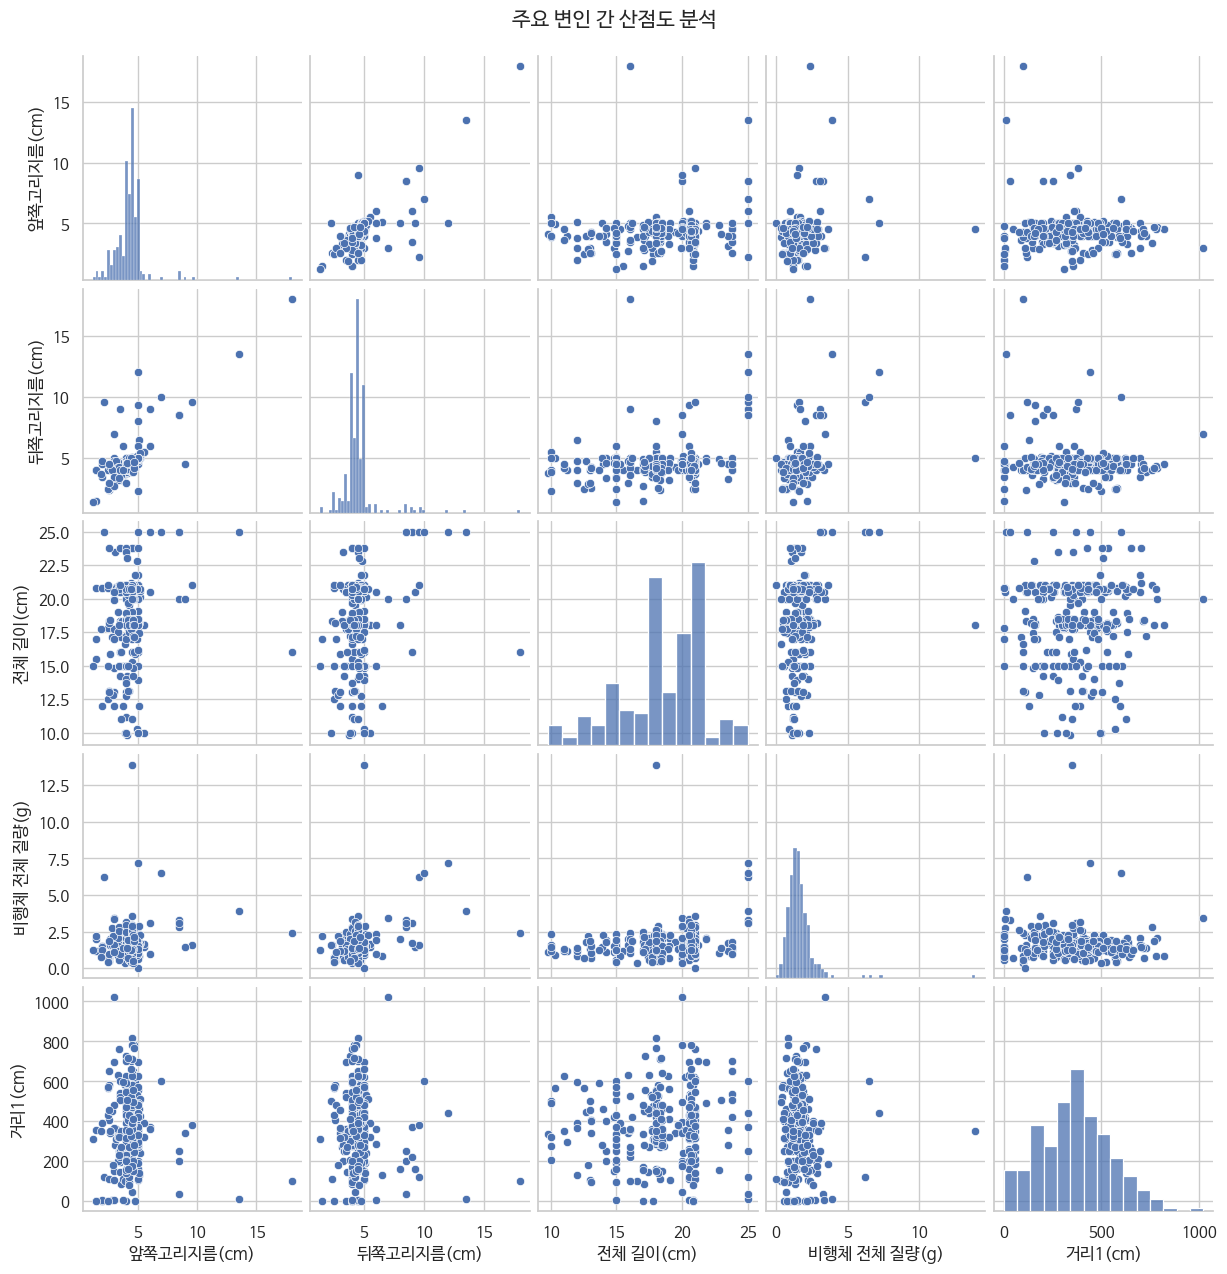

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy as np

# 폰트 경로 직접 지정 및 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
fm.fontManager.addfont(font_path)

# 전역 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 수치형 데이터만 선택
numeric_df = df.select_dtypes(include=[np.number])

# 1. 히트맵
plt.figure(figsize=(14, 10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('고리 비행기 변인 간 상관관계 분석 (Heatmap)', fontproperties=font_prop, fontsize=15)
plt.show()

# 2. 산점도 행렬
selected_cols = ['앞쪽고리지름(cm)', '뒤쪽고리지름(cm)', '전체 길이(cm)', '비행체 전체 질량(g)', '거리1(cm)']
sns.set(font='NanumBarunGothic', style='whitegrid')
pg = sns.pairplot(df[selected_cols])
pg.fig.suptitle('주요 변인 간 산점도 분석', y=1.02, fontproperties=font_prop, fontsize=15)

# 축 라벨 한글 깨짐 방지
for ax in pg.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontproperties=font_prop)
        ax.set_ylabel(ax.get_ylabel(), fontproperties=font_prop)

plt.show()

3. 머신러닝 모델 학습 (회귀 분석)

In [18]:
# 2. 독립변수(X)와 종속변수(y) 설정
# 데이터에 존재하는 '거리1(cm)'을 예측 목표(y)로 설정합니다.
target_col = '거리1(cm)' # 예측하고자 하는 값 (Outcome -> 거리1(cm)으로 수정)
features = df.columns.drop(target_col) # 나머지 변수들을 독립변수로 사용

X = df[features]
y = df[target_col]

# 3. 데이터 분할 (훈련 비율 0.8 설정)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. 모델 생성 및 학습 (랜덤 포레스트)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. 결과 예측 및 평가
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)

print(f"모델 설명력 (R^2): {r2:.4f}")
# R^2가 0.7 이상이면 매우 신뢰할 수 있는 결과로 해석합니다.

모델 설명력 (R^2): 0.8607


4. 결과 해석 및 변수 중요도 시각화

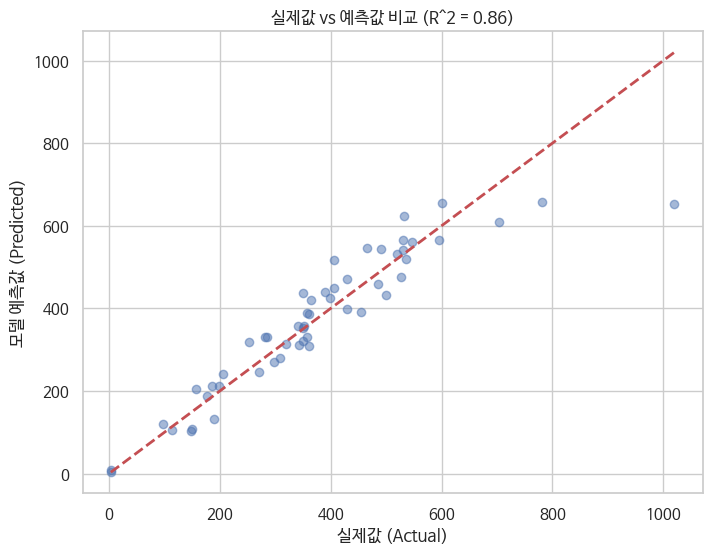

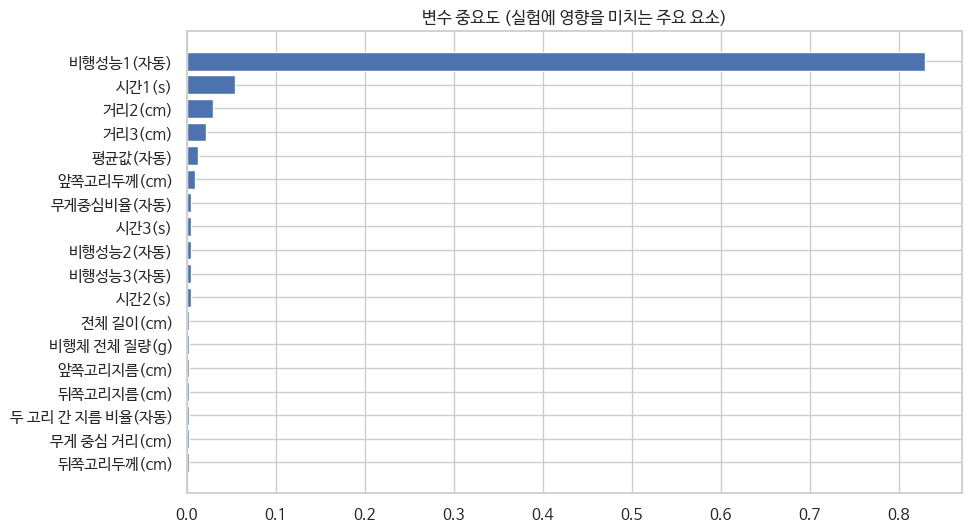

In [19]:
# 한글 폰트 깨짐 방지 재적용 (이전 셀에서 적용되었어도 확실하게 다시 적용)
plt.rc('font', family='NanumBarunGothic')

# 실제값 vs 예측값 시각화
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('실제값 (Actual)')
plt.ylabel('모델 예측값 (Predicted)')
plt.title(f'실제값 vs 예측값 비교 (R^2 = {r2:.2f})')
plt.show()

# 변수 중요도 시각화 (실험에 가장 큰 영향을 미치는 요소 찾기)
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.barh(features[indices], importances[indices])
plt.title('변수 중요도 (실험에 영향을 미치는 주요 요소)')
plt.show()

5. 보고서 산출

In [20]:
import base64
from io import BytesIO
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 한글 폰트 설정 (보고서 이미지에 적용)
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False # 마이너스 폰트 깨짐 방지

def fig_to_base64(fig):
    buf = BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight', dpi=300)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode('utf-8')

In [21]:
# 1. 각 그래프를 시각화하고 base64 문자열로 변환

# 상관관계 히트맵
fig1, ax1 = plt.subplots(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', ax=ax1)
ax1.set_title('Correlation Heatmap')
heatmap_b64 = fig_to_base64(fig1)
plt.close(fig1)

# 산점도 행렬
selected_cols = ['앞쪽고리지름(cm)', '전체 길이(cm)', '거리1(cm)']
pg = sns.pairplot(df[selected_cols])
pairplot_b64 = fig_to_base64(pg.fig)
plt.close(pg.fig)

# 실제값 vs 예측값
fig2, ax2 = plt.subplots(figsize=(8, 6))
ax2.scatter(y_test, y_pred, alpha=0.5)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual')
ax2.set_ylabel('Predicted')
actual_pred_b64 = fig_to_base64(fig2)
plt.close(fig2)

# 변수 중요도
fig3, ax3 = plt.subplots(figsize=(10, 6))
importances = model.feature_importances_
indices = np.argsort(importances)
ax3.barh(df.columns.drop(target_col)[indices], importances[indices])
ax3.set_title('Feature Importance')
importance_b64 = fig_to_base64(fig3)
plt.close(fig3)

# 2. HTML 콘텐츠 생성
html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title>고리 비행기 데이터 분석 보고서</title>
    <style>
        body {{ font-family: 'NanumBarunGothic', sans-serif; margin: 20px; line-height: 1.6; }}
        h1, h2 {{ color: #333; }}
        img {{ max-width: 100%; height: auto; display: block; margin: 15px 0; border: 1px solid #ddd; padding: 5px; background-color: #fff; }}
        .section {{ margin-bottom: 30px; padding: 20px; border: 1px solid #eee; background-color: #f9f9f9; border-radius: 8px; }}
    </style>
</head>
<body>
    <h1>고리 비행기 데이터 분석 보고서</h1>
    <div class="section">
        <h2>1. 데이터 로드 및 확인</h2>
        <pre><code>{df.head().to_html()}</code></pre>
    </div>
    <div class="section">
        <h2>2. 데이터 시각화 및 상관관계 분석</h2>
        <img src="data:image/png;base64,{heatmap_b64}" alt="Heatmap">
        <img src="data:image/png;base64,{pairplot_b64}" alt="Pairplot">
    </div>
    <div class="section">
        <h2>3. 머신러닝 모델 학습 (R^2: {r2:.4f})</h2>
        <img src="data:image/png;base64,{actual_pred_b64}" alt="Actual vs Predicted">
    </div>
    <div class="section">
        <h2>4. 변수 중요도</h2>
        <img src="data:image/png;base64,{importance_b64}" alt="Importance">
    </div>
</body>
</html>
"""

with open('고리_비행기_데이터_분석_보고서.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("보고서 파일 '고리_비행기_데이터_분석_보고서.html'이 생성되었습니다.")

보고서 파일 '고리_비행기_데이터_분석_보고서.html'이 생성되었습니다.


In [22]:
# 생성된 HTML 보고서 다운로드
files.download('고리_비행기_데이터_분석_보고서.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>